In [ ]:
import pandas as pd
from hiprof.base.id import ID
from hiprof.base.graph import Graph
from hiprof.verification.falsifier import HPFalsifier

Define two graphs and find two formulas with the ID algorithm.

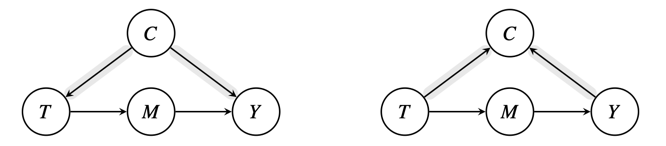

In [ ]:
nodes_A = ["T", "M", "Y", "C"]
directed_A = pd.DataFrame(
    [[0, 1, 0, 0],
     [0, 0, 1, 0],
     [0, 0, 0, 0],
     [1, 0, 1, 0]],
    index=nodes_A,
    columns=nodes_A,
)
graph_A = Graph(directed_A)

In [ ]:
id_A = ID(treatments='T', outcomes='Y', graph=graph_A)
formula_A = id_A.run()
formula_A

In [ ]:
falsifier_A = HPFalsifier(treatments='T', outcomes='Y', graph=graph_A)
falsifier_A.check(formula_A)

In [ ]:
nodes_B = ["T", "M", "Y", "C"]
directed_B = pd.DataFrame(
    [[0, 1, 0, 1],
     [0, 0, 1, 0],
     [0, 0, 0, 1],
     [0, 0, 0, 0]],
    index=nodes_B,
    columns=nodes_B,
)
graph_B = Graph(directed_B)

In [ ]:
id_B = ID(treatments='T', outcomes='Y', graph=graph_B)
formula_B = id_B.run()
formula_B

In [ ]:
falsifier_B = HPFalsifier(treatments='T', outcomes='Y', graph=graph_B)
falsifier_B.check(formula_B)

Check that the formula found in one graph cannot be used for the other.

In [ ]:
falsifier_A.check(formula_B)

In [ ]:
falsifier_B.check(formula_A)

Find a formula that holds for both.

In [ ]:
alternative_formula = "SUM_{M} { p(M | T=.) SUM_{T} { p(Y | T, M) p(T) } }"

In [ ]:
falsifier_A.check(alternative_formula)

In [ ]:
falsifier_B.check(alternative_formula)